# Xenium Prime Human Lymph Node Dataset

### Gene set activity quantification and germinal-center radial composition

This notebook demonstrates GESSO on the 10x Xenium Prime human reactive lymph node FFPE dataset (~709,000 cells). We score four lymph-node-relevant pathways and perform a downstream germinal-center (GC) radial composition analysis, which examines how the dominant transcriptional program (B-cell, T-cell, or intercellular transport) shifts as a function of distance from each GC's center.

Pathways scored:

- `GOBP_LYMPHOCYTE_ACTIVATION` - broad lymphocyte activation
- `HADDAD_B_LYMPHOCYTE_PROGENITOR` - B-cell program (dominant within GC cores)
- `HAY_BONE_MARROW_NAIVE_T_CELL` - T-cell program (interfollicular zones)
- `GOBP_VESICLE_MEDIATED_TRANSPORT` - intercellular transport program

### Import the `gesso` package

The `gesso` Python package can be easily downloaded from source. Simply run the following script in your terminal after ensuring Python and pip are available in your environment. We recommend installing GESSO in a new Python environment.

```bash
git clone https://github.com/YMa-Lab/GESSO.git
cd GESSO
pip install .
cd ..
```

Reading the Xenium Prime data additionally requires `scanpy`, `scipy`, and `pyarrow`:

```bash
pip install scanpy scipy pyarrow
```

In [1]:
from pathlib import Path
import sys
import time
import warnings

import numpy as np
import pandas as pd
import scipy.io as sio
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", message="Variable names are not unique")

project_directory = Path("__notebook__").resolve().parent.parent
sys.path.append(str(project_directory))

from gesso import GESSO

### Configure logging (optional)

In [ ]:
from gesso import logging as glog

glog.enable()
glog.silence_per_geneset();  # keep summaries, mute per-geneset progress


### Load the spatial transcriptomics data

In [3]:
xenium_root = Path(
    "/users/ayang103/data/Spatial/raw/10x_XeniumPrime2/Xenium_Prime_Human_Lymph_Node_Reactive_FFPE_outs"
)
mtx_dir = xenium_root / "cell_feature_matrix"
matrix_mtx = mtx_dir / "matrix.mtx.gz"
barcodes_tsv = mtx_dir / "barcodes.tsv.gz"
features_tsv = mtx_dir / "features.tsv.gz"
cells_parquet = xenium_root / "cells.parquet"

pathways_csv = Path(
    "/users/ayang103/data/Project/SPLAGE/Target_Pathway_List/PathwaysTable/used_geneset"
    "/XeniumPrime.HumanLymphNode.PathwaysTable.0517.csv"
)
gc_labels_csv = Path(
    "/users/ayang103/data/Project/SPLAGE/SPLAGE_Project_Analysis"
    "/10x_XeniumPrime2/human_lymph_node/full_labeled_data-062525.csv"
)
for p in (matrix_mtx, barcodes_tsv, features_tsv, cells_parquet, pathways_csv, gc_labels_csv):
    assert p.exists(), p

In [ ]:
t0 = time.time()
mat = sio.mmread(str(matrix_mtx)).T.tocsr()
barcodes = pd.read_csv(barcodes_tsv, header=None, sep="\t")[0].astype(str).values
features = pd.read_csv(features_tsv, header=None, sep="\t")
print(f"loaded MTX in {time.time() - t0:.1f}s; shape (cells x genes) = {mat.shape}")

# build AnnData
adata = sc.AnnData(mat)
adata.obs_names = barcodes
adata.var["feature_id"] = features[0].values
adata.var["feature_name"] = features[1].values
adata.var_names = adata.var["feature_name"].astype(str).values
adata.var_names_make_unique()

t0 = time.time()
expression_df: pd.DataFrame = pd.DataFrame(
    adata.X.toarray(), index=adata.obs_names, columns=adata.var_names
)
print(f"materialized dense expression in {time.time() - t0:.1f}s; shape = {expression_df.shape}")
display(expression_df.iloc[:5, :8])

loaded MTX in 11.6s; shape (cells x genes) = (708983, 11094)


materialized dense expression in 6.1s; shape = (708983, 11094)


,A2ML1,AAMP,AAR2,AARSD1,ABAT,ABCA1,ABCA3,ABCA4
aaaaadoa-1,0,0,0,0,0,1,0,0
aaaaclhf-1,0,0,0,0,0,0,0,0
aaaafcfj-1,0,0,0,0,0,0,0,0
aaaagamp-1,0,0,0,0,0,0,0,0
aaaaiako-1,0,0,0,0,0,0,0,0


In [ ]:
locations_df = pd.read_parquet(str(cells_parquet))
locations_df = locations_df.set_index("cell_id")
locations_df = locations_df.rename(columns={"x_centroid": "x", "y_centroid": "y"})[["x", "y"]]
display(locations_df.head())
print("locations shape:", locations_df.shape)

# align expression and locations on cell IDs
common_cells = expression_df.index.intersection(locations_df.index)
expression_df = expression_df.loc[common_cells]
locations_df = locations_df.loc[common_cells]
print("after cell-id intersect:", expression_df.shape, locations_df.shape)

# drop cells with < 50 total counts
cell_total_counts = expression_df.sum(axis=1)
keep = cell_total_counts >= 50
expression_df = expression_df.loc[keep]
locations_df = locations_df.loc[keep]
print("after >=50 counts filter:", expression_df.shape, locations_df.shape)

,x,y
cell_id,,
aaaaadoa-1,2871.859619,347.729767
aaaaclhf-1,2882.301025,349.938110
aaaafcfj-1,2880.217041,338.575897
aaaagamp-1,2852.795166,356.880615
aaaaiako-1,2854.036133,361.754639


locations shape: (708983, 2)


after cell-id intersect: (708983, 11094) (708983, 2)


after >=50 counts filter: (681601, 11094) (681601, 2)


Load the gene-set membership matrix. The pathway table is a $G \times n_\text{genesets}$ binary matrix.

In [ ]:
pathways = [
    "GOBP_LYMPHOCYTE_ACTIVATION",
    "HADDAD_B_LYMPHOCYTE_PROGENITOR",
    "HAY_BONE_MARROW_NAIVE_T_CELL",
    "GOBP_VESICLE_MEDIATED_TRANSPORT",
]

genesets_df = pd.read_csv(
    pathways_csv, index_col=0, usecols=["Unnamed: 0", *pathways]
)
genesets_df = genesets_df[pathways]
genesets_df.columns.name = None
genesets_df.index.name = None
for pw in pathways:
    n_in_panel = int(genesets_df.loc[genesets_df.index.intersection(expression_df.columns), pw].sum())
    print(f"{pw}: {int(genesets_df[pw].sum())} genes in set, {n_in_panel} present in Xenium Prime panel")
display(genesets_df.iloc[:5])

GOBP_LYMPHOCYTE_ACTIVATION: 466 genes in set, 466 present in Xenium Prime panel
HADDAD_B_LYMPHOCYTE_PROGENITOR: 106 genes in set, 106 present in Xenium Prime panel
HAY_BONE_MARROW_NAIVE_T_CELL: 87 genes in set, 87 present in Xenium Prime panel
GOBP_VESICLE_MEDIATED_TRANSPORT: 517 genes in set, 517 present in Xenium Prime panel


,GOBP_LYMPHOCYTE_ACTIVATION,HADDAD_B_LYMPHOCYTE_PROGENITOR,HAY_BONE_MARROW_NAIVE_T_CELL,GOBP_VESICLE_MEDIATED_TRANSPORT
A2ML1,0,0,0,0
AAMP,0,0,0,0
AAR2,0,0,0,0
AARSD1,0,0,0,0
ABAT,0,0,0,0


### Use GESSO to compute gene set activity scores

We use the `lowres` method with `n_partitions=100` (~7,000 cells per partition) and `stratified_kmeans` partitioning. Each of the 4 gene sets is scored across all 100 spatial partitions, which the `Parallel` pool processes concurrently.

In [ ]:
model = GESSO(
    expression_df=expression_df,
    locations_df=locations_df,
    genesets_df=genesets_df,
    k=20,                                 # number of nearest-neighbor edges for the spatial graph
    normalize_counts_method="normalize-log1p",
)

start = time.time()
gas_report = model.compute_gas(
    genesets=pathways,
    beta=0.33,                            # spatial smoothing strength
    compute_method="lowres",              # scalable estimator for hundreds of thousands of cells
    partition_method="stratified_kmeans",
    n_partitions=100,
    n_jobs=30,
    store_gene_contributions=True,
)
print(f"compute_gas done in {(time.time() - start) / 60:.1f} min for {len(pathways)} gene sets")

gas_df = gas_report.gas_df()
display(gas_df.head())

GESSO (info): Removed 6470 genes not found in geneset data. 4624 genes remain. 


GESSO (info): Removed 6470 genes not found in expression data. 4624 genes remain. 


GESSO (info): Identified 4624 common genes in the gene set and expression data. 


GESSO (info): Identified 681601 common spots in the location and expression data. 


GESSO (info): Normalized expression data with strategy 'normalize-log1p'. 


GESSO (info): Model initialization complete. 


GESSO (info): Beginning low resolution activity score computation for 4 gene sets with 4 
               jobs. Method used: lowres. 


compute_gas done in 44.4 min for 4 gene sets


,GOBP_LYMPHOCYTE_ACTIVATION,HADDAD_B_LYMPHOCYTE_PROGENITOR,HAY_BONE_MARROW_NAIVE_T_CELL,GOBP_VESICLE_MEDIATED_TRANSPORT
aaaaadoa-1,-0.246292,0.677588,-0.951902,2.345646
aaaaclhf-1,-1.889258,0.053906,2.235382,-1.584156
aaaafcfj-1,-2.553608,-0.665536,1.675503,-1.283997
aaaagamp-1,-1.993401,-1.300194,2.395186,0.100114
aaaaiako-1,0.758302,-1.386747,-3.243969,-0.071914


Top gene contributions per pathway

In [8]:
for pw in pathways:
    top = gas_report.gene_contributions_df(geneset=pw).head(8)
    print(f"\n=== top contributors: {pw} ===")
    print(top)


=== top contributors: GOBP_LYMPHOCYTE_ACTIVATION ===
           GOBP_LYMPHOCYTE_ACTIVATION
MS4A1                        0.264720
CD19                         0.222732
CD22                         0.222535
CD79A                        0.220627
TNFRSF13C                    0.205247
BANK1                        0.177762
CD79B                        0.161926
POU2AF1                      0.152683

=== top contributors: HADDAD_B_LYMPHOCYTE_PROGENITOR ===
       HADDAD_B_LYMPHOCYTE_PROGENITOR
MS4A1                        0.383065
CD22                         0.327860
CD19                         0.325526
CD79A                        0.319652
BANK1                        0.263157
CD79B                        0.244955
CIITA                        0.230422
PAX5                         0.220702

=== top contributors: HAY_BONE_MARROW_NAIVE_T_CELL ===
        HAY_BONE_MARROW_NAIVE_T_CELL
CD3E                        0.317816
TCF7                        0.228702
LEF1                        0.196381


### Visualize spatial maps for the four pathways

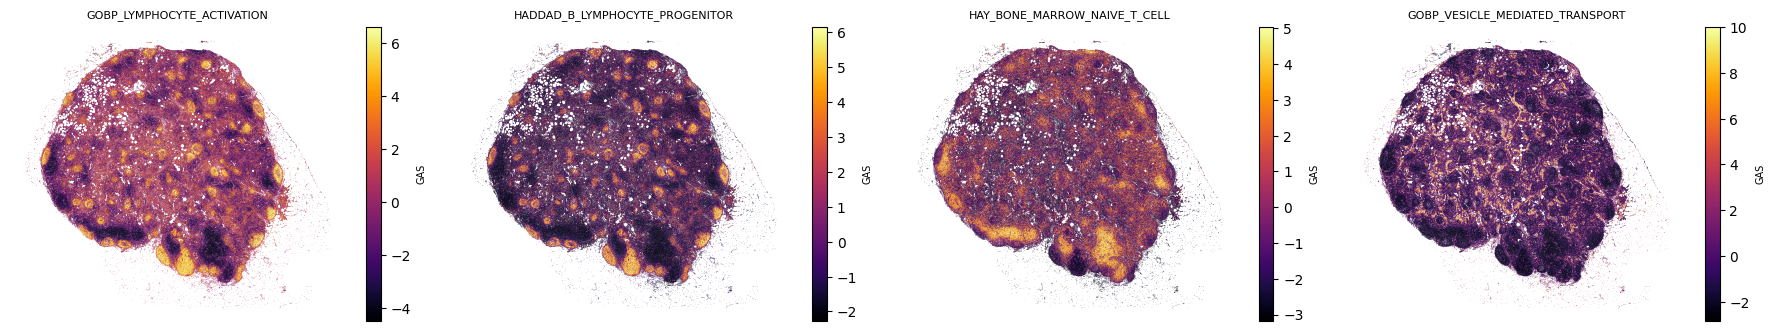

In [9]:
fig, axes = plt.subplots(1, len(pathways), figsize=(4.5 * len(pathways), 4.5))
for ax, pw in zip(axes, pathways):
    values = gas_df[pw].to_numpy()
    vmin = float(np.percentile(values, 1))
    vmax = float(np.percentile(values, 99))
    sc_plt = ax.scatter(
        locations_df["x"].to_numpy(), locations_df["y"].to_numpy(),
        c=values, cmap="inferno", s=0.3, marker=".", linewidths=0,
        vmin=vmin, vmax=vmax, rasterized=True,
    )
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(pw, fontsize=8)
    fig.colorbar(sc_plt, ax=ax, shrink=0.7).set_label("GAS", fontsize=7)
fig.tight_layout()
display(fig)
plt.close(fig)

### Downstream analysis: radial composition of dominant pathway from GC centroids

The dominant transcriptional program within and around germinal centers (GCs) shifts smoothly with radial distance from the GC core. B-cell-specific activity dominates within GCs and decays outward, while T-cell and intercellular-transport activity rise toward and beyond the GC boundary.

Here we perform this analysis using the GC annotations. Each cell in `full_labeled_data-062525.csv` carries a `label` column with `0` for non-GC cells and positive integers (1-44) for cells belonging to individual GCs. We:

1. pick three representative GCs (the three with the most cells)
2. for each, compute its centroid and an effective radius (the 90th percentile of distances from the centroid to its assigned cells); this becomes “1 normalized radius”
3. for every nearby cell, determine which of the three relevant pathways (`HADDAD_B_LYMPHOCYTE_PROGENITOR`, `HAY_BONE_MARROW_NAIVE_T_CELL`, `GOBP_VESICLE_MEDIATED_TRANSPORT`) is dominant after slice-wide z-scoring
4. bin cells by normalized radial distance and plot the fraction of cells dominated by each pathway as a function of radius

The broad `GOBP_LYMPHOCYTE_ACTIVATION` pathway is correlated with the B-cell program and is not part of the three-way dominance comparison.

In [ ]:
# load GC labels (one row per cell, same barcodes as cells.parquet)
labels_df = pd.read_csv(gc_labels_csv).set_index("barcode")
print("labels rows:", len(labels_df))
print("non-GC cells (label=0):", int((labels_df["label"] == 0).sum()))
print("GC cells (label>0):    ", int((labels_df["label"] > 0).sum()))
print("number of distinct GCs:", int((labels_df["label"] > 0).sum() and labels_df.loc[labels_df["label"] > 0, "label"].nunique()))

# align to cells that survived the >=50 counts filter
labels_df = labels_df.loc[labels_df.index.intersection(locations_df.index)]
print("labels aligned to filtered cells:", labels_df.shape)

# choose the 3 GCs with the most cells
gc_sizes = labels_df.loc[labels_df["label"] > 0, "label"].value_counts()
selected_gcs = gc_sizes.head(3).index.tolist()
print("selected GCs (label, n_cells):")
for gc_id in selected_gcs:
    print(f"  GC {gc_id}: {int(gc_sizes.loc[gc_id])} cells")

labels rows: 708983
non-GC cells (label=0): 676235
GC cells (label>0):     32748
number of distinct GCs: 44


labels aligned to filtered cells: (681601, 3)
selected GCs (label, n_cells):
  GC 2: 4981 cells
  GC 9: 2076 cells
  GC 1: 1668 cells


In [ ]:
# z-score each of the 3 pathways across the full slice and pick argmax per cell
dominance_pathways = [
    "HADDAD_B_LYMPHOCYTE_PROGENITOR",
    "HAY_BONE_MARROW_NAIVE_T_CELL",
    "GOBP_VESICLE_MEDIATED_TRANSPORT",
]
dominance_labels = {
    "HADDAD_B_LYMPHOCYTE_PROGENITOR": "B cell",
    "HAY_BONE_MARROW_NAIVE_T_CELL": "T cell",
    "GOBP_VESICLE_MEDIATED_TRANSPORT": "transport",
}
dominance_colors = {
    "B cell": "#d7191c",
    "T cell": "#2c7bb6",
    "transport": "#2ca25f",
}

z_df = gas_df[dominance_pathways].copy()
z_df = (z_df - z_df.mean(axis=0)) / z_df.std(axis=0, ddof=0)
dominant_idx = z_df.to_numpy().argmax(axis=1)
dominant_pw_per_cell = pd.Series(
    [dominance_labels[dominance_pathways[i]] for i in dominant_idx],
    index=z_df.index,
    name="dominant",
)
print("dominant pathway counts (all cells):")
print(dominant_pw_per_cell.value_counts())

dominant pathway counts (all cells):


dominant
T cell       278782
transport    212699
B cell       190120
Name: count, dtype: int64


In [ ]:
# compute centroid and effective radius for each selected GC, then radial profile
N_BINS = 20
MAX_NORM_RADIUS = 3.0
bin_edges = np.linspace(0.0, MAX_NORM_RADIUS, N_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

cell_xy = locations_df[["x", "y"]].to_numpy()
cell_index = locations_df.index

gc_profiles = {}
for gc_id in selected_gcs:
    gc_cell_ids = labels_df.index[labels_df["label"] == gc_id]
    gc_coords = locations_df.loc[gc_cell_ids, ["x", "y"]].to_numpy()
    centroid = gc_coords.mean(axis=0)
    own_dists = np.linalg.norm(gc_coords - centroid, axis=1)
    radius = float(np.percentile(own_dists, 90))
    print(f"GC {gc_id}: n={len(gc_cell_ids)}, centroid=({centroid[0]:.1f}, {centroid[1]:.1f}), radius90={radius:.2f}")

    # all cells within MAX_NORM_RADIUS of the centroid
    all_dists = np.linalg.norm(cell_xy - centroid, axis=1)
    norm_dists = all_dists / radius
    in_window = norm_dists <= MAX_NORM_RADIUS
    window_cells = cell_index[in_window]
    window_norm = norm_dists[in_window]
    window_dom = dominant_pw_per_cell.loc[window_cells].to_numpy()
    print(f"  cells within {MAX_NORM_RADIUS} normalized radii: {window_cells.size}")

    bin_idx = np.clip(np.digitize(window_norm, bin_edges) - 1, 0, N_BINS - 1)
    profile_rows = []
    for b in range(N_BINS):
        mask = bin_idx == b
        n_in_bin = int(mask.sum())
        if n_in_bin == 0:
            profile_rows.append({"r": bin_centers[b], "n": 0, "B cell": np.nan, "T cell": np.nan, "transport": np.nan})
            continue
        dom_in_bin = window_dom[mask]
        profile_rows.append({
            "r": bin_centers[b],
            "n": n_in_bin,
            "B cell": float((dom_in_bin == "B cell").mean()),
            "T cell": float((dom_in_bin == "T cell").mean()),
            "transport": float((dom_in_bin == "transport").mean()),
        })
    gc_profiles[gc_id] = {
        "centroid": centroid,
        "radius": radius,
        "n_cells": int(len(gc_cell_ids)),
        "profile": pd.DataFrame(profile_rows),
    }

GC 2: n=4981, centroid=(4441.6, 6103.1), radius90=212.78
  cells within 3.0 normalized radii: 22967
GC 9: n=2076, centroid=(6731.0, 4630.9), radius90=172.81
  cells within 3.0 normalized radii: 15777
GC 1: n=1668, centroid=(3826.1, 5850.2), radius90=164.81
  cells within 3.0 normalized radii: 9962


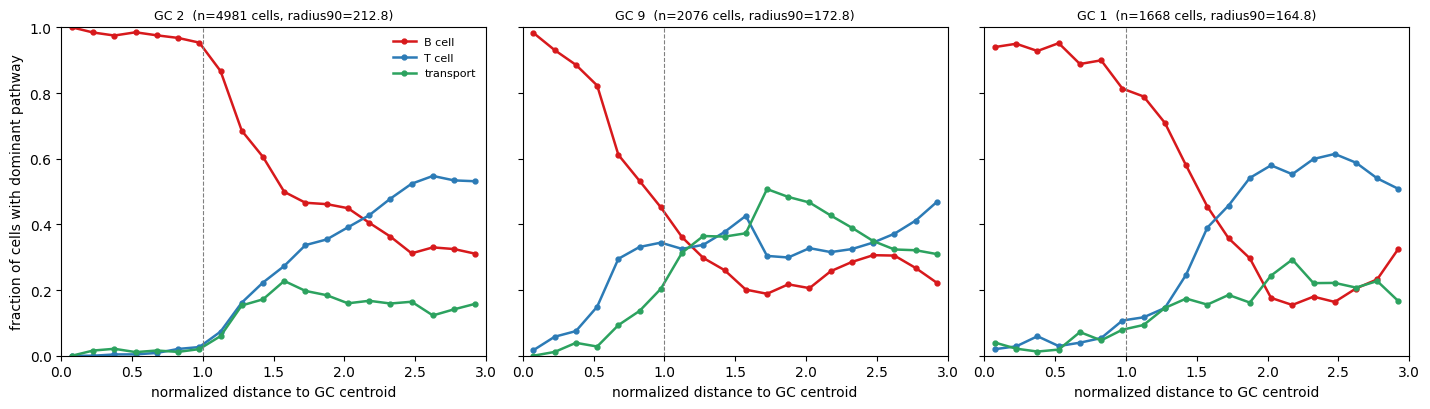

In [13]:
fig, axes = plt.subplots(1, len(selected_gcs), figsize=(4.8 * len(selected_gcs), 4.2), sharey=True)
for ax, gc_id in zip(axes, selected_gcs):
    prof = gc_profiles[gc_id]["profile"]
    for cat in ["B cell", "T cell", "transport"]:
        ax.plot(prof["r"], prof[cat], color=dominance_colors[cat], lw=1.8, label=cat, marker="o", ms=3.5)
    ax.axvline(1.0, color="grey", lw=0.8, ls="--")
    ax.set_xlim(0, MAX_NORM_RADIUS)
    ax.set_ylim(0, 1)
    ax.set_xlabel("normalized distance to GC centroid")
    ax.set_title(
        f"GC {gc_id}  (n={gc_profiles[gc_id]['n_cells']} cells, "
        f"radius90={gc_profiles[gc_id]['radius']:.1f})",
        fontsize=9,
    )
    if ax is axes[0]:
        ax.set_ylabel("fraction of cells with dominant pathway")
        ax.legend(loc="upper right", fontsize=8, frameon=False)
fig.tight_layout()
display(fig)
plt.close(fig)

Each panel shows that within the GC core, B-cell-specific activity dominates the cellular composition, consistent with these structures being sites of intense B-cell activation, clonal expansion, and affinity maturation. Beyond the GC boundary, the T-cell and intercellular-transport programs take over. GESSO recovers the spatial organization of immune function at single-cell resolution.